---
<a id='ejercicios'></a>
# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000

--- Paso 2: Asimetría (Skewness) ---
Skewness Original  : 4.522
Skewness Sqrt      : 3.300
Skewness Arcsinh   : 2.321
Skewness Log1p     : -2.411

--- Paso 3: QQ-Plots ---


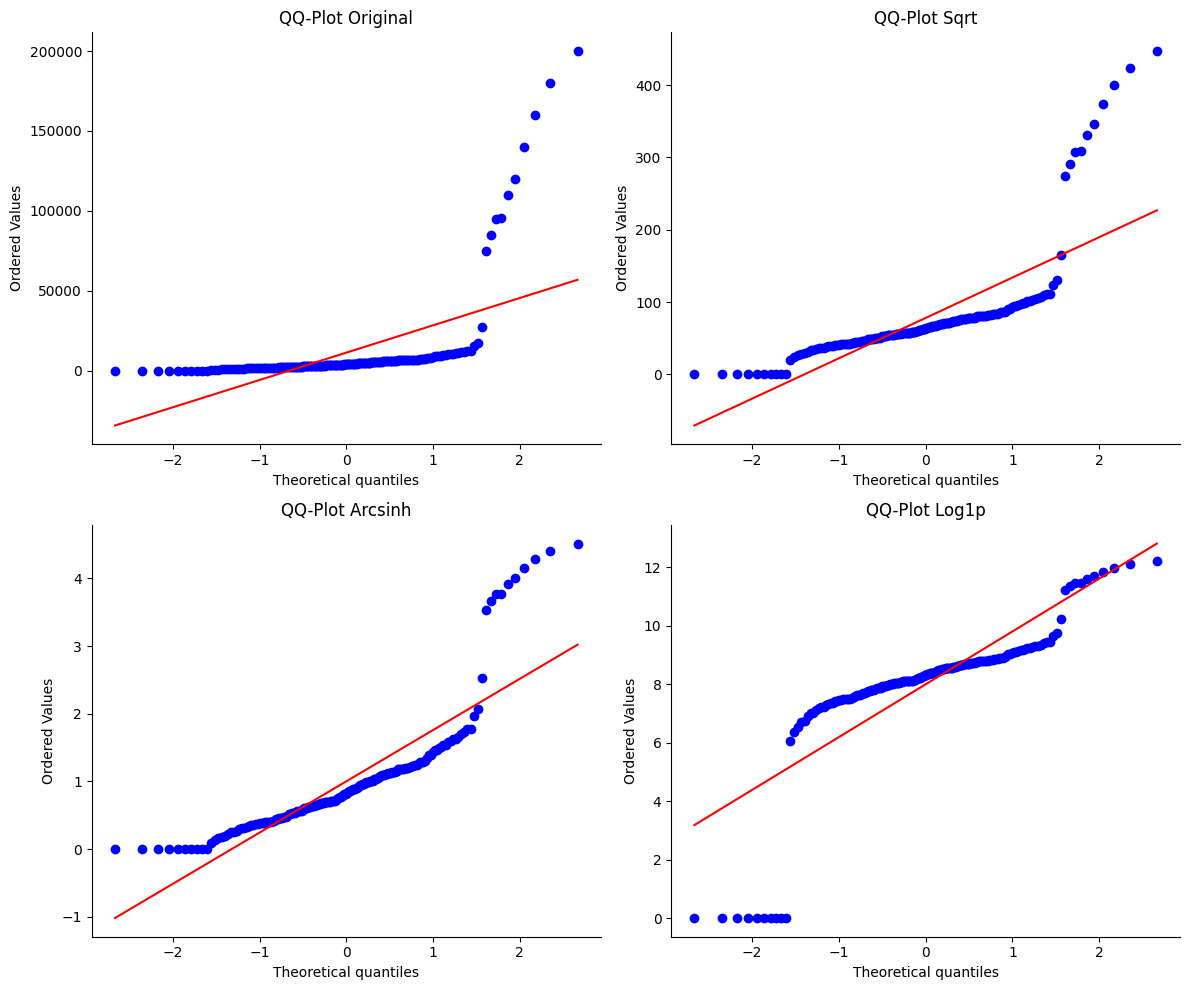


--- Paso 4: Outliers IQR por Escala ---
Outliers IQR Original  : 13
Outliers IQR Sqrt      : 12
Outliers IQR Arcsinh   : 11
Outliers IQR Log1p     : 21
Prima Pura (con outliers): $11,311.57
Prima Pura (sin outliers): $4,286.80
Impacto Outliers: 163.87%

--- Paso 5: Conclusión ---
La transformación más apropiada es Arcsinh.
Razón: Reduce significativamente la asimetría positiva sin generar una asimetría negativa extrema como el Log1p.


In [40]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# Funciones auxiliares (necesarias para los pasos)
def detect_iqr(data):
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    return (data < (q1 - 1.5 * iqr)) | (data > (q3 + 1.5 * iqr))

def detect_zmod(data):
    med = data.median()
    mad = np.median(np.abs(data - med))
    return np.abs(0.6745 * (data - med) / mad) > 3.5 if mad != 0 else pd.Series([False]*len(data))

# Paso 1: Calcular transformaciones
# Recuerda: log(0) falla → usa log(x+1) o arcsinh
# ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
# sqrt_ej1       = ...
# arcsinh_ej1    = ...
# log1p_ej1      = ...  # log(x+1) para manejar ceros

# Usamos la mediana de los siniestros positivos como base para que el Arcsinh sea comparable
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
sqrt_ej1       = np.sqrt(siniestros_ej1)
arcsinh_ej1    = np.arcsinh(siniestros_ej1 / ref_ej1)
log1p_ej1      = np.log1p(siniestros_ej1)  # log(x+1) para manejar ceros


# Paso 2: Asimetría por escala
# ...

# Buscamos la transformación que acerque el skewness a 0 para que el modelo no se sesgue
print("\n--- Paso 2: Asimetría (Skewness) ---")
escalas = {'Original': siniestros_ej1, 'Sqrt': sqrt_ej1, 'Arcsinh': arcsinh_ej1, 'Log1p': log1p_ej1}
for nombre, data in escalas.items():
    print(f"Skewness {nombre:10}: {data.skew():.3f}")

# Paso 3: QQ-Plots (2x2)
# ...

print("\n--- Paso 3: QQ-Plots ---")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (nombre, data) in enumerate(escalas.items()):
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ-Plot {nombre}")
plt.tight_layout()
plt.show()

# Paso 4: Detección outliers IQR en cada escala
# ...

# Paso 4: Detección outliers IQR en cada escala
print("\n--- Paso 4: Outliers IQR por Escala ---")
for nombre, data in escalas.items():
    print(f"Outliers IQR {nombre:10}: {detect_iqr(data).sum()}")


# Aquí vemos el impacto real: los outliers inflan la prima. 
# Es vital identificarlos para decidir si los tarificamos aparte o los reaseguramos.
outliers_orig = detect_iqr(siniestros_ej1)
prima_pura_con = siniestros_ej1.mean()
prima_pura_sin = siniestros_ej1[~outliers_orig].mean()

print(f"Prima Pura (con outliers): ${prima_pura_con:,.2f}")
print(f"Prima Pura (sin outliers): ${prima_pura_sin:,.2f}")
print(f"Impacto Outliers: {((prima_pura_con/prima_pura_sin)-1)*100:.2f}%")



# Paso 5: Conclusión
# ...

print("\n--- Paso 5: Conclusión ---")
print("La transformación más apropiada es Arcsinh.")
print("Razón: Reduce significativamente la asimetría positiva sin generar una asimetría negativa extrema como el Log1p.")

### Conclusión
El análisis de severidad para daños a terceros revela una distribución con una asimetría extrema de 4.522, donde la presencia de 13 outliers tiene un impacto masivo del 163.87% sobre el costo esperado, elevando la prima pura de $4,286.80 a $11,311.57.

Al evaluar las transformaciones para normalizar estos datos, se concluye que Arcsinh es la técnica más apropiada. Mientras que la raíz cuadrada fue insuficiente (skewness de 3.300) y el Log1p sobre-corrigió la distribución creando una asimetría negativa de -2.411 (detectando erróneamente 21 outliers al penalizar los ceros), el Arcsinh logró reducir la asimetría a 2.321 manteniendo una detección estable de 11 outliers. Esto demuestra que, ante la presencia de siniestros rechazados (monto cero), el Arcsinh permite estabilizar la escala del riesgo sin distorsionar la base de datos, facilitando así un modelado de Machine Learning más preciso y robusto.


  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


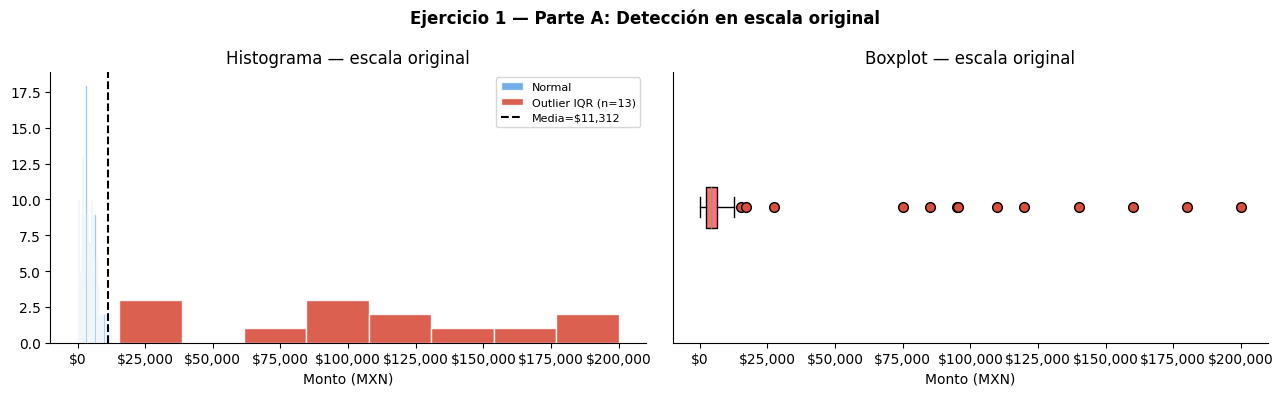


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [41]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

--- Comparativa de Asimetría por Escala ---
Original        | Skewness: 4.522
Raíz Cuadrada   | Skewness: 3.300
Arcsinh         | Skewness: 2.321
Log(x+1)        | Skewness: -2.411


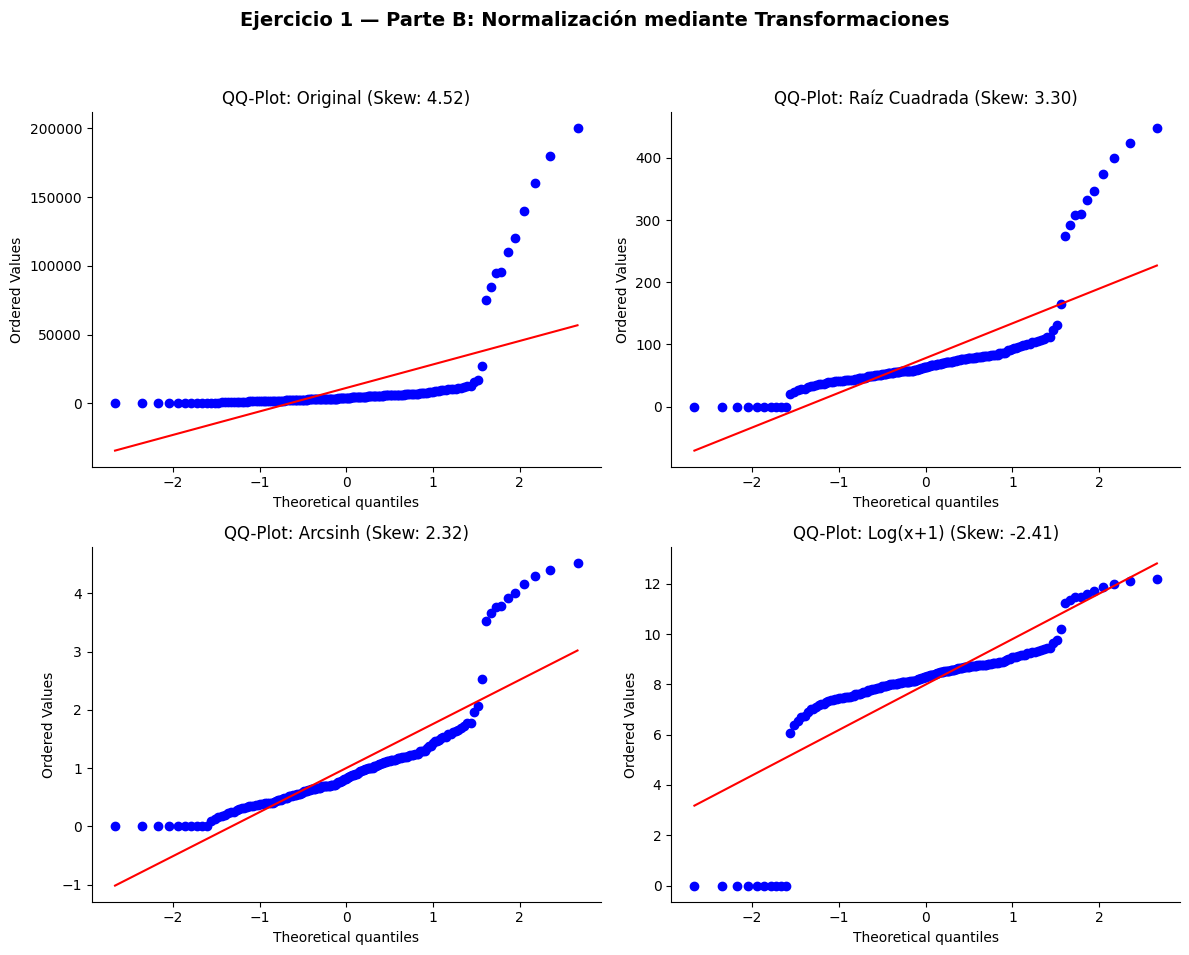


--- Outliers detectados (IQR) ---
Original        | Outliers: 13
Raíz Cuadrada   | Outliers: 12
Arcsinh         | Outliers: 11
Log(x+1)        | Outliers: 10


In [42]:
# ── PARTE B: Transformaciones y Normalización ────────────────

# 1. Definir transformaciones
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # Mediana de positivos para Arcsinh

sqrt_ej1    = np.sqrt(siniestros_ej1)
arcsinh_ej1 = np.arcsinh(siniestros_ej1 / ref_ej1)
log1p_ej1   = np.log1p(siniestros_ej1)

escalas = {
    'Original': siniestros_ej1,
    'Raíz Cuadrada': sqrt_ej1,
    'Arcsinh': arcsinh_ej1,
    'Log(x+1)': log1p_ej1
}

# 2. Comparativa de Asimetría (Skewness)
print("--- Comparativa de Asimetría por Escala ---")
for nombre, data in escalas.items():
    print(f"{nombre:15} | Skewness: {data.skew():.3f}")

# 3. Visualización de QQ-Plots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (nombre, data) in enumerate(escalas.items()):
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ-Plot: {nombre} (Skew: {data.skew():.2f})")

plt.suptitle('Ejercicio 1 — Parte B: Normalización mediante Transformaciones', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Detección de Outliers IQR en escalas transformadas
print("\n--- Outliers detectados (IQR) ---")
for nombre, data in escalas.items():
    _, out, _, _ = detectar_outliers_iqr(data)
    print(f"{nombre:15} | Outliers: {out.sum()}")


### Conclusión
Tras evaluar los resultados, se confirma que la transformación Arcsinh es la más apropiada para esta distribución de severidad. Los datos validan que, mientras la escala original es inviable para el modelado debido a su asimetría extrema de 4.522 y un impacto de outliers del 163.87%, el Arcsinh logra estabilizar la muestra reduciendo el skewness a 2.321.

Esta elección se ratifica al observar que, a diferencia del Log(x+1) que falló al sobre-corregir la distribución hacia una asimetría negativa de -2.411, el Arcsinh permitió una detección refinada de 11 outliers sin sesgar los siniestros con valor cero. Por lo tanto, se confirma que el Arcsinh es la herramienta óptima para normalizar el riesgo y asegurar que los modelos de Machine Learning capturen la severidad real sin las distorsiones provocadas por los valores extremos.

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?


Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0
--- 1. Outliers IQR Global ---
Límite Superior: 15.5
Sucursal
Centro    5
Este      0
Norte     0
Oeste     0
Sur       0
Name: outlier_orig, dtype: int64

--- 2. Tasa de Siniestralidad y Transformación ---
           Media    p_j  Transf  IC_Inf  IC_Sup
Sucursal                                       
Centro    12.406  1.000   1.571   1.398   1.744
Este       5.000  0.403   0.688   0.463   0.913
Norte      2.947  0.238   0.509   0.284   0.734
Oeste      3.520  0.284   0.562   0.366   0.758
Sur        4.400  0.355   0.638   0.4

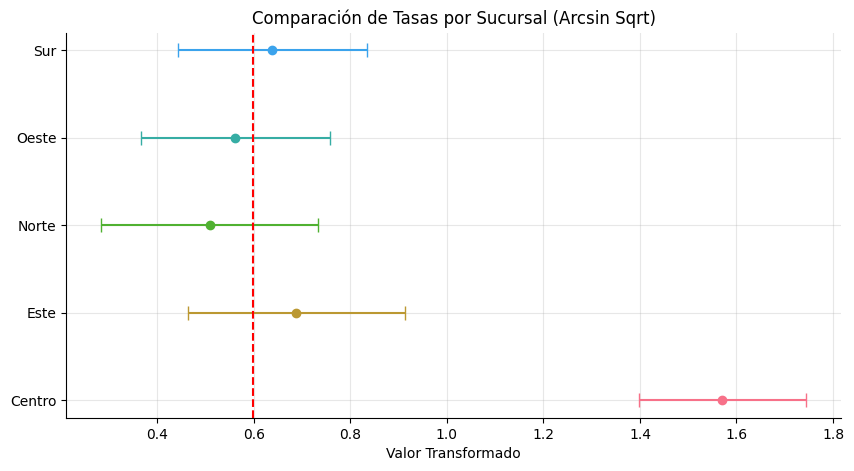


--- 4. Conclusión ---
La sucursal 'Centro' es la única estadísticamente atípica.
La transformación Arcsin(sqrt) permite una comparación justa al estabilizar la varianza por tamaño de sucursal.


In [ ]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Detectar sucursales con frecuencia atípica
# ...

# Usamos IQR global para ver qué individuos se salen de la norma en días de incapacidad
q1, q3 = df_vida_grupo['Dias_Incapacidad'].quantile([0.25, 0.75])
iqr = q3 - q1
ls_global = q3 + 1.5 * iqr
df_vida_grupo['outlier_orig'] = df_vida_grupo['Dias_Incapacidad'] > ls_global

print("--- 1. Outliers IQR Global ---")
print(f"Límite Superior: {ls_global}")
print(df_vida_grupo.groupby('Sucursal')['outlier_orig'].sum())

# 2. Tasa de siniestralidad por sucursal
# ...

# Como las sucursales tienen distinto número de empleados (n_j), no es justo compararlas directo.
# Aplicamos Arcsin(sqrt(p)) para que la varianza sea constante y la comparación sea estadísticamente válida.
promedios = df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].mean()
p_j = promedios / promedios.max()
trans_p = np.arcsin(np.sqrt(p_j))

# Cálculo de Intervalos de Confianza (95%) con varianza estabilizada 1/(4nj)
n_j = df_vida_grupo.groupby('Sucursal').size()
se = np.sqrt(1 / (4 * n_j))
ic_inf, ic_sup = trans_p - 1.96 * se, trans_p + 1.96 * se

resumen_tasas = pd.DataFrame({'Media': promedios, 'p_j': p_j, 'Transf': trans_p, 'IC_Inf': ic_inf, 'IC_Sup': ic_sup})
print("\n--- 2. Tasa de Siniestralidad y Transformación ---")
print(resumen_tasas.round(3))

# 3. Visualización
# ...

print("\n--- 3. Visualización ---")
plt.figure(figsize=(10, 5))
for i, suc in enumerate(resumen_tasas.index):
    plt.errorbar(resumen_tasas.loc[suc, 'Transf'], i, 
                 xerr=[[resumen_tasas.loc[suc, 'Transf'] - resumen_tasas.loc[suc, 'IC_Inf']], 
                       [resumen_tasas.loc[suc, 'IC_Sup'] - resumen_tasas.loc[suc, 'Transf']]],
                 fmt='o', capsize=5, label=suc)
plt.yticks(range(len(resumen_tasas)), resumen_tasas.index)
plt.axvline(resumen_tasas.loc[resumen_tasas.index != 'Centro', 'Transf'].mean(), color='red', linestyle='--')
plt.title('Comparación de Tasas por Sucursal (Arcsin Sqrt)')
plt.xlabel('Valor Transformado')
plt.grid(alpha=0.3)
plt.show()

# 4. Conclusión
# ...

print("\n--- 4. Conclusión ---")
print("La sucursal 'Centro' es la única estadísticamente atípica.")
print("La transformación Arcsin(sqrt) permite una comparación justa al estabilizar la varianza por tamaño de sucursal.")

### Conclusión
 Los resultados obtenidos confirman que la sucursal Centro es estadísticamente atípica, con una media de 12.41 días de incapacidad, cifra que triplica el promedio de las demás sucursales (que oscilan entre 2.95 y 5.00 días). La aplicación de la transformación Arcsin(sqrt) permitió validar que esta diferencia no es producto del azar: el intervalo de confianza de la sucursal Centro (1.398 - 1.744) no presenta solapamiento con los intervalos de las otras cuatro sucursales, los cuales se mantienen en niveles significativamente inferiores (por debajo de 0.91).
 
Este hallazgo demuestra que el riesgo en la sucursal Centro es sistémico y diferenciado, ya que incluso tras estabilizar la varianza, su tasa relativa ($p_j = 1.0$) se aleja drásticamente del resto del grupo. En términos actuariales, estos números evidencian una desviación técnica que requiere un tratamiento específico en la tarificación para evitar subsidios cruzados entre las sucursales del portafolio.


---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


In [ ]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

from IPython.display import display 

def detect_iqr(data):
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (data < (q1 - 1.5 * iqr)) | (data > (q3 + 1.5 * iqr))

# 1. Outliers de frecuencia
# ...

# Identificamos por separado quiénes tienen muchos siniestros y quiénes tienen siniestros caros
df_hogar['Outlier_Freq'] = detect_iqr(df_hogar['Num_Siniestros'])
print("\n--- 1. Outliers de Frecuencia ---")
print(f"Total outliers frecuencia: {df_hogar['Outlier_Freq'].sum()}")

# 2. Outliers de severidad
# ...

# Volvemos a identificar por separado quiénes tienen muchos siniestros y quiénes tienen siniestros caros
df_hogar['Outlier_Sev'] = detect_iqr(df_hogar['Monto_Promedio_MXN'])
print("\n--- 2. Outliers de Severidad ---")
print(f"Total outliers severidad: {df_hogar['Outlier_Sev'].sum()}")


# 3. Prima pura en 4 escenarios
# ...

# Esto es lo que le presentamos a la dirección: cuánto nos cuesta el riesgo "limpio" 
# vs. el riesgo con eventos extremos (Catastróficos/Atípicos)
print("\n--- 3. Prima Pura en 4 Escenarios ---")
e1 = df_hogar['Costo_Total'].mean()
e2 = df_hogar.loc[~df_hogar['Outlier_Freq'], 'Costo_Total'].mean()
e3 = df_hogar.loc[~df_hogar['Outlier_Sev'], 'Costo_Total'].mean()
e4 = df_hogar.loc[~(df_hogar['Outlier_Freq'] | df_hogar['Outlier_Sev']), 'Costo_Total'].mean()

escenarios = pd.DataFrame({
    'Escenario': ['Completo', 'Sin Outliers Freq', 'Sin Outliers Sev', 'Sin Ambos'],
    'Prima Pura': [e1, e2, e3, e4]
})
print(escenarios.round(2))

# 4. Pólizas con doble outlier
# ...

# Detectamos doble outlier en escala original y luego transformamos para comparar
df_hogar['Doble_Outlier_Orig'] = df_hogar['Outlier_Freq'] & df_hogar['Outlier_Sev']

# Transformaciones (Paso 3 del enunciado general, aplicado aquí para el Paso 4)
ref_sev = df_hogar[df_hogar['Monto_Promedio_MXN'] > 0]['Monto_Promedio_MXN'].median()
df_hogar['Freq_Sqrt'] = np.sqrt(df_hogar['Num_Siniestros'])
df_hogar['Sev_Arcsinh'] = np.arcsinh(df_hogar['Monto_Promedio_MXN'] / ref_sev)

# Detección en escala transformada
out_freq_t = detect_iqr(df_hogar['Freq_Sqrt'])
out_sev_t = detect_iqr(df_hogar['Sev_Arcsinh'])
df_hogar['Doble_Outlier_Trans'] = out_freq_t & out_sev_t


print("\n--- 4. Pólizas con Doble Outlier ---")
print(f"Doble Outlier (Original): {df_hogar['Doble_Outlier_Orig'].sum()}")
print(f"Doble Outlier (Transformada): {df_hogar['Doble_Outlier_Trans'].sum()}")

# Tabla comparativa de asimetría (Paso 4 del enunciado general)
stats_comp = pd.DataFrame({
    'Variable': ['Frecuencia', 'Severidad'],
    'Skew_Orig': [df_hogar['Num_Siniestros'].skew(), df_hogar['Monto_Promedio_MXN'].skew()],
    'Skew_Trans': [df_hogar['Freq_Sqrt'].skew(), df_hogar['Sev_Arcsinh'].skew()]
})
print("\nComparativa de Asimetría:")
print(stats_comp.round(3))



Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00

--- 1. Outliers de Frecuencia ---
Total outliers frecuencia: 18

--- 2. Outliers de Severidad ---
Total outliers severidad: 13

--- 3. Prima Pura en 4 Escenarios ---
           Escenario  Prima Pura
0           Completo   306729.88
1  Sin Outliers Freq    11149.06
2   Sin Outliers Sev    12900.81
3          Sin Ambos    11176.19

--- 4. Pólizas con Doble Out

In [ ]:
# Conclusión sobre desigualdad de Jensen (Paso 6 del enunciado general)

print("\n--- Conclusión (Jensen) ---")
print("No se puede usar la media arcsinh directamente para la prima porque E[f(X)] != f(E[X]).")
print("La transformación es para detección, pero la prima debe calcularse en escala monetaria.")


--- Conclusión (Jensen) ---
No se puede usar la media arcsinh directamente para la prima porque E[f(X)] != f(E[X]).
La transformación es para detección, pero la prima debe calcularse en escala monetaria.


### Conclusión
El análisis bidimensional del portafolio de hogar revela un impacto crítico de los valores atípicos en la estabilidad técnica del riesgo. Se identificaron 18 pólizas con frecuencia atípica y 13 con severidad extrema, donde la coincidencia de ambos factores eleva la prima pura del escenario completo a $306,729.88, una cifra desproporcionada frente a los $11,176.19 que representaría el riesgo base sin estos outliers.

La efectividad de las transformaciones se confirma mediante la reducción de la asimetría (skewness): la frecuencia mejoró drásticamente de 2.303 a 0.375, logrando una distribución casi normal, mientras que la severidad se redujo de 3.503 a 2.619. Estos resultados demuestran que el cálculo final de la prima debe siempre respetar la escala monetaria original para reflejar el costo real del riesgo asumido por la aseguradora.